# Telco Customer Churn — Analysis Notebook

## Project Overview

This notebook analyzes customer churn for a telecom provider using the Telco Customer Churn dataset (7,043 customers, 21 features covering demographics, account details, and subscribed services).

**Business objective:** identify which customer attributes and service-usage patterns are associated with churn, and build a predictive model to flag at-risk customers so retention efforts can be targeted efficiently rather than applied broadly.

**Dataset:** `WA_FnUseC_TelcoCustomerChurn.csv` — one row per customer; target variable is `Churn` (Yes/No).

## Workflow & Notebook Structure

This notebook follows a standard data analysis workflow (loosely mirroring CRISP-DM: Business Understanding -> Data Understanding -> Data Preparation -> Modeling -> Evaluation):

| Part | Stage | What it covers |
|---|---|---|
| 1 | Data Understanding | Load raw data, inspect structure, dtypes, and initial data-quality signals |
| 2 | Data Preparation | Fix `TotalCharges` dtype, handle the 11 blank rows, recode `SeniorCitizen`, sanity checks |
| 3 | Exploratory Data Analysis | Target balance, churn rate by segment, numeric distributions, tenure-based patterns |
| 4 | Feature Engineering | Encode categorical variables, scale numeric features, train/test split |
| 5 | Model Training | Train candidate models (Logistic Regression, KNN, Decision Tree, Random Forest, Gradient Boosting) |
| 6 | Model Evaluation & Comparison | Cross-validated and held-out metrics — accuracy, precision, recall, F1, ROC-AUC; ROC curve comparison |
| 7 | Feature Importance & Recommendations | Interpret the best model, identify top churn drivers, translate into business recommendations |

*Parts 1-3 are implemented below. Parts 4-7 will be appended in later sections as we build them out.*

## Notes & Conventions

- **Environment:** Python 3, requires `pandas`, `numpy`, `matplotlib`, `seaborn`, `scikit-learn`.
- **Run order matters:** cells are meant to be run top-to-bottom; later parts assume the cleaned `df` produced in Part 2, not the raw CSV.
- **Metric choice:** churn is moderately imbalanced (~26.5% positive class), so accuracy alone is not a reliable metric for model comparison — precision, recall, F1, and ROC-AUC are used throughout instead.
- **Scope & limitations:** EDA (Part 3) findings are univariate/correlational, not causal. Modeling (Parts 4-6) is multivariate but still observational — no experiment was run, so the churn drivers identified are candidates for retention action, not proven causes.

## Part 1: Setup & Data Loading

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
%matplotlib inline

Load the raw CSV. Update the path below to wherever the file lives in your project.

In [23]:
df = pd.read_csv('data\WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(df.shape)
df.head()

(7043, 21)


<>:1: SyntaxWarning: "\W" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\W"? A raw string is also an option.
<>:1: SyntaxWarning: "\W" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\W"? A raw string is also an option.
C:\Users\Trucn\AppData\Local\Temp\ipykernel_2308\2894197394.py:1: SyntaxWarning: "\W" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\W"? A raw string is also an option.
  df = pd.read_csv('data\WA_Fn-UseC_-Telco-Customer-Churn.csv')


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [24]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

**Initial observations to check:**
- `TotalCharges` is loaded as `object` (string) instead of numeric — that's a red flag, investigated in Part 2.
- All other columns look like sensible types (`int64`/`float64`/`object`).
- No missing values reported by `.info()` — but that's because blanks in `TotalCharges` are empty strings, not `NaN`, so pandas doesn't catch them yet.

In [25]:
df.isna().sum().sum()  # 0 -- confirms missing values are hidden as blank strings, not NaN

np.int64(0)

## Part 2: Data Cleaning

Two issues to fix before any analysis: `TotalCharges` stuck as text, and `SeniorCitizen` encoded as 0/1 instead of readable labels.

### 2.1 Fix `TotalCharges`

Force it to numeric. Anything that isn't a valid number (the blank strings) becomes `NaN`, which we can then actually detect.

In [26]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print('Rows with missing TotalCharges:', df['TotalCharges'].isna().sum())

Rows with missing TotalCharges: 11


Let's look at those rows before deciding what to do with them.

In [27]:
df[df['TotalCharges'].isna()][['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']]

,tenure,MonthlyCharges,TotalCharges,Churn
488,0,52.55,NaN,No
753,0,20.25,NaN,No
936,0,80.85,NaN,No
1082,0,25.75,NaN,No
1340,0,56.05,NaN,No
3331,0,19.85,NaN,No
3826,0,25.35,NaN,No
4380,0,20.00,NaN,No
5218,0,19.70,NaN,No
6670,0,73.35,NaN,No


**All 11 rows have `tenure = 0`** — brand-new customers who haven't been billed yet, so `TotalCharges` is genuinely undefined for them (not a data-entry error). Two options: impute as 0, or drop them.

They're 0.16% of the data and all have `Churn = No` (new customers, no time to churn), so dropping them is safe and won't bias the analysis. Imputing 0 would also work, but since `tenure=0` customers can't meaningfully be analyzed for churn drivers anyway, dropping is cleaner.

In [28]:
df = df.dropna(subset=['TotalCharges']).reset_index(drop=True)
print('New shape:', df.shape)

New shape: (7032, 21)


### 2.2 Recode `SeniorCitizen`

It's stored as `0`/`1` while every other Yes/No flag in the dataset uses text — remap it for consistency and readability.

In [29]:
df['SeniorCitizen'] = df['SeniorCitizen'].map({0: 'No', 1: 'Yes'})
df['SeniorCitizen'].value_counts()

SeniorCitizen
No     5890
Yes    1142
Name: count, dtype: int64

### 2.3 Sanity checks

Confirm no duplicate customers and no remaining nulls.

In [30]:
print('Duplicate customerIDs:', df['customerID'].duplicated().sum())
print('Duplicate rows:', df.duplicated().sum())
print('Remaining nulls:\n', df.isna().sum()[df.isna().sum() > 0])
print('\nFinal shape:', df.shape)

Duplicate customerIDs: 0
Duplicate rows: 0
Remaining nulls:
 Series([], dtype: int64)

Final shape: (7032, 21)


**Cleaning summary:** dropped 11 rows with undefined `TotalCharges` (tenure=0 customers), recoded `SeniorCitizen` to Yes/No, confirmed no duplicates and no remaining nulls. Dataset is now **7,032 rows x 21 columns**, ready for EDA.

## Part 3: Exploratory Data Analysis

Goal: find which features actually separate churners from non-churners, before we build any model.

### 3.1 Target balance

Check the Churn split first — this determines whether accuracy alone will be a trustworthy metric later.

Churn
No     73.4
Yes    26.6
Name: proportion, dtype: float64


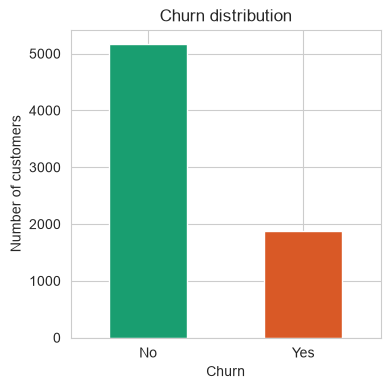

In [31]:
churn_counts = df['Churn'].value_counts(normalize=True) * 100
print(churn_counts.round(1))

fig, ax = plt.subplots(figsize=(4,4))
df['Churn'].value_counts().plot(kind='bar', color=['#199e70', '#d95926'], ax=ax)
ax.set_title('Churn distribution')
ax.set_ylabel('Number of customers')
plt.xticks(rotation=0)
plt.show()

**~73.5% No / 26.5% Yes.** Moderate imbalance — not extreme, but a model that always predicts "No churn" would already score 73.5% accuracy while being useless. We'll rely on precision/recall/F1/ROC-AUC later, not accuracy alone.

### 3.2 Churn rate by categorical segment

For each key categorical column, compute the churn rate within each group. This is more informative than raw counts — it shows *risk*, not just volume.

In [32]:
cat_features = ['Contract', 'InternetService', 'PaymentMethod', 'OnlineSecurity',
                'TechSupport', 'SeniorCitizen', 'Dependents', 'Partner', 'PaperlessBilling']

for col in cat_features:
    rate = df.groupby(col)['Churn'].apply(lambda x: (x == 'Yes').mean() * 100).sort_values(ascending=False)
    print(f'--- {col} ---')
    print(rate.round(1).astype(str) + '%')
    print()

--- Contract ---
Contract
Month-to-month    42.7%
One year          11.3%
Two year           2.8%
Name: Churn, dtype: str

--- InternetService ---
InternetService
Fiber optic    41.9%
DSL            19.0%
No              7.4%
Name: Churn, dtype: str

--- PaymentMethod ---
PaymentMethod
Electronic check             45.3%
Mailed check                 19.2%
Bank transfer (automatic)    16.7%
Credit card (automatic)      15.3%
Name: Churn, dtype: str

--- OnlineSecurity ---
OnlineSecurity
No                     41.8%
Yes                    14.6%
No internet service     7.4%
Name: Churn, dtype: str

--- TechSupport ---
TechSupport
No                     41.6%
Yes                    15.2%
No internet service     7.4%
Name: Churn, dtype: str

--- SeniorCitizen ---
SeniorCitizen
Yes    41.7%
No     23.7%
Name: Churn, dtype: str

--- Dependents ---
Dependents
No     31.3%
Yes    15.5%
Name: Churn, dtype: str

--- Partner ---
Partner
No     33.0%
Yes    19.7%
Name: Churn, dtype: str

--- Paperle

Now the same story as a single sorted chart, so the biggest risk factors jump out visually.

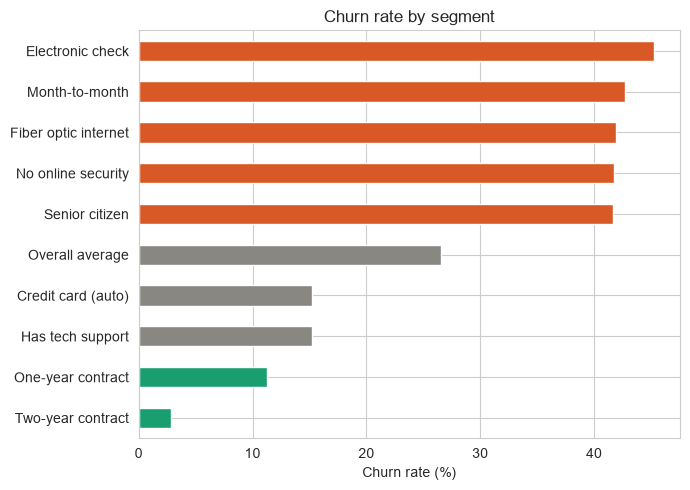

In [33]:
segment_rates = {
    'Two-year contract': df[df.Contract=='Two year'],
    'Credit card (auto)': df[df.PaymentMethod=='Credit card (automatic)'],
    'Has tech support': df[df.TechSupport=='Yes'],
    'One-year contract': df[df.Contract=='One year'],
    'No online security': df[df.OnlineSecurity=='No'],
    'Fiber optic internet': df[df.InternetService=='Fiber optic'],
    'Senior citizen': df[df.SeniorCitizen=='Yes'],
    'Electronic check': df[df.PaymentMethod=='Electronic check'],
    'Month-to-month': df[df.Contract=='Month-to-month'],
}
rates = {k: (v['Churn']=='Yes').mean()*100 for k, v in segment_rates.items()}
rates['Overall average'] = (df['Churn']=='Yes').mean()*100
rates = pd.Series(rates).sort_values()

fig, ax = plt.subplots(figsize=(7,5))
colors = ['#199e70' if v <= 15 else ('#898781' if v < 30 else '#d95926') for v in rates.values]
rates.plot(kind='barh', color=colors, ax=ax)
ax.set_xlabel('Churn rate (%)')
ax.set_title('Churn rate by segment')
plt.tight_layout()
plt.show()

**Contract type dominates**: two-year contracts churn at 2.8% vs. 42.7% for month-to-month — a ~15x gap. Electronic check payment, fiber optic internet, no online security, and senior citizen status are the next strongest single-variable risk factors, all roughly 40%+ vs. the 26.5% baseline.

### 3.3 Numeric features vs. churn

Compare tenure, monthly charges, and total charges between churners and non-churners.

       tenure  MonthlyCharges  TotalCharges
Churn                                      
No       37.7            61.3        2555.3
Yes      18.0            74.4        1531.8


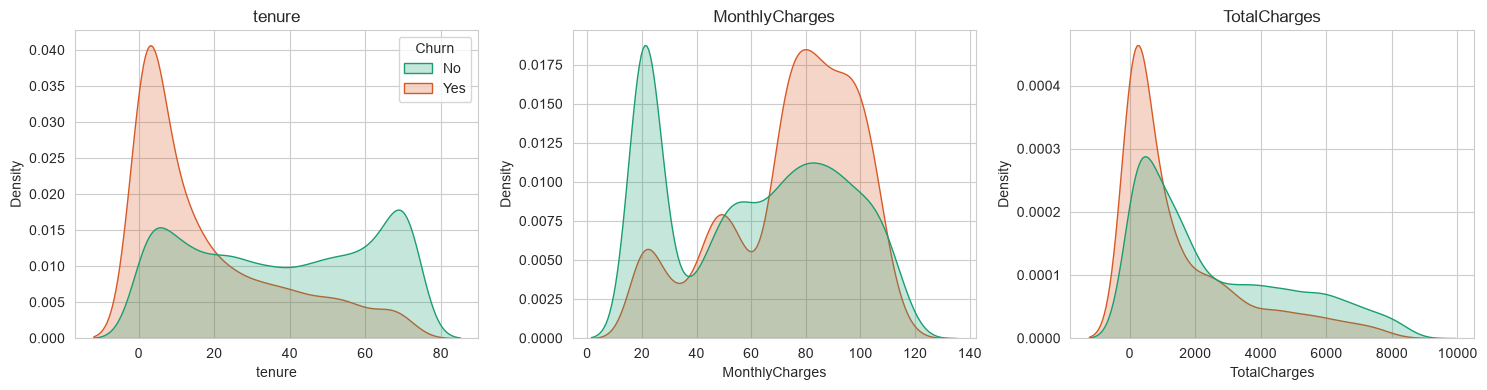

In [34]:
print(df.groupby('Churn')[['tenure', 'MonthlyCharges', 'TotalCharges']].mean().round(1))

fig, axes = plt.subplots(1, 3, figsize=(15,4))
for ax, col in zip(axes, ['tenure', 'MonthlyCharges', 'TotalCharges']):
    sns.kdeplot(data=df, x=col, hue='Churn', fill=True, common_norm=False,
                palette={'No': '#199e70', 'Yes': '#d95926'}, ax=ax, legend=(col=='tenure'))
    ax.set_title(col)
plt.tight_layout()
plt.show()

Churners have much shorter tenure (18.0 vs 37.7 months average) and slightly higher monthly charges ($74.4 vs $61.3) but lower total charges (they simply haven't been around long enough to accumulate spend). Tenure is the clearest separator of the three.

### 3.4 Churn rate by tenure bucket

Break tenure into bands to see the shape of the relationship, not just the average.

tenure_bucket
0-12     47.7
13-24    28.7
25-48    20.4
49-60    14.4
61-72     6.6
Name: Churn, dtype: float64


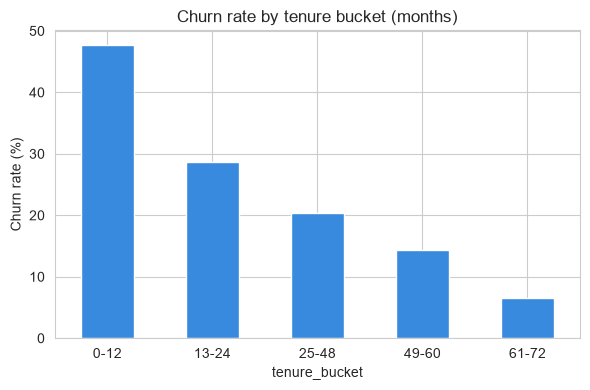

In [35]:
df['tenure_bucket'] = pd.cut(df['tenure'], bins=[0,12,24,48,60,72],
                              labels=['0-12','13-24','25-48','49-60','61-72'])
tenure_churn = df.groupby('tenure_bucket', observed=True)['Churn'].apply(lambda x: (x=='Yes').mean()*100)
print(tenure_churn.round(1))

fig, ax = plt.subplots(figsize=(6,4))
tenure_churn.plot(kind='bar', color='#378ADD', ax=ax)
ax.set_ylabel('Churn rate (%)')
ax.set_title('Churn rate by tenure bucket (months)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Classic early-life churn curve**: 47.7% churn in months 0-12, dropping steadily to 6.6% by months 61-72. Customers who make it past the first year are dramatically more likely to stay.

### EDA takeaways going into modeling
- `Contract`, `tenure`, `InternetService`, `PaymentMethod`, and security/support add-ons are the strongest churn signals.
- The relationship with tenure looks monotonic/roughly linear in log-odds — a good sign that even a simple linear model (logistic regression) should perform reasonably, which we'll verify in Part 6.
- Target is moderately imbalanced (26.5% churn) — metric choice in Part 6 needs to account for this.

## Part 4: Feature Engineering

Goal: turn the cleaned dataframe into a numeric feature matrix a model can actually consume, and split it properly so evaluation later is trustworthy.

### 4.1 Define target and drop non-predictive columns

- `customerID` is an identifier — no predictive signal, would just add noise/overfitting risk.
- `tenure_bucket` was created in Part 3 purely for plotting; it's a discretized copy of `tenure`, so keeping both would be redundant (and could confuse a linear model with collinear inputs).
- Target: `Churn` converted to a 0/1 integer, since scikit-learn classifiers expect numeric labels.

In [36]:
model_df = df.drop(columns=['customerID', 'tenure_bucket'])

y = (model_df['Churn'] == 'Yes').astype(int)
X = model_df.drop(columns=['Churn'])

print('Feature matrix shape:', X.shape)
print('Target balance:', y.value_counts(normalize=True).round(3).to_dict())

Feature matrix shape: (7032, 19)
Target balance: {0: 0.734, 1: 0.266}


### 4.2 Encode categorical variables

One-hot encode every text column with `pd.get_dummies`. `drop_first=True` drops one category per column (it becomes the implicit "baseline") to avoid perfect multicollinearity between dummy columns — important for logistic regression in particular, where redundant columns can destabilize the coefficients.

In [37]:
cat_cols = X.select_dtypes(include='object').columns.tolist()
num_cols = X.select_dtypes(exclude='object').columns.tolist()

print('Categorical columns:', len(cat_cols))
print('Numeric columns:', num_cols)

X_enc = pd.get_dummies(X, columns=cat_cols, drop_first=True)
print('\nEncoded feature matrix shape:', X_enc.shape)
X_enc.head()

Categorical columns: 16
Numeric columns: ['tenure', 'MonthlyCharges', 'TotalCharges']

Encoded feature matrix shape: (7032, 30)


C:\Users\Trucn\AppData\Local\Temp\ipykernel_2308\1719584633.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include='object').columns.tolist()


,tenure,MonthlyCharges,TotalCharges,gender_Male,SeniorCitizen_Yes,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,29.85,29.85,False,False,True,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,True,False
1,34,56.95,1889.50,True,False,False,False,True,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,True
2,2,53.85,108.15,True,False,False,False,True,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,True
3,45,42.30,1840.75,True,False,False,False,False,True,False,False,False,False,True,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False,False
4,2,70.70,151.65,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False


### 4.3 Train/test split

80/20 split, **stratified on `y`** so both sets preserve the same ~26.5% churn ratio as the full dataset — otherwise a random split could accidentally over- or under-represent churners in the test set and make metrics unreliable. `random_state=42` fixes the split so results are reproducible on re-run.

In [38]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_enc, y, test_size=0.2, stratify=y, random_state=42
)

print('Train shape:', X_train.shape, ' Churn rate:', y_train.mean().round(3))
print('Test shape: ', X_test.shape,  ' Churn rate:', y_test.mean().round(3))

Train shape: (5625, 30)  Churn rate: 0.266
Test shape:  (1407, 30)  Churn rate: 0.266


### 4.4 Scale numeric features

`tenure`, `MonthlyCharges`, and `TotalCharges` live on very different scales (0-72 vs. ~19-119 vs. ~19-8700). Distance- and gradient-based models (Logistic Regression, KNN) are sensitive to that and need standardization; tree-based models (Decision Tree, Random Forest, Gradient Boosting) split on raw thresholds and don't need it — scaling them would be harmless but pointless.

**Important:** the scaler is `fit` on the training set only, then applied (`transform`) to the test set. Fitting on the full dataset before splitting would leak test-set statistics (mean/std) into training — a subtle form of data leakage that inflates reported performance.

In [39]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

X_train_scaled[num_cols].describe().round(2)

,tenure,MonthlyCharges,TotalCharges
count,5625.00,5625.00,5625.00
mean,-0.00,0.00,0.00
std,1.00,1.00,1.00
min,-1.29,-1.55,-1.00
25%,-0.96,-0.97,-0.83
50%,-0.15,0.19,-0.39
75%,0.96,0.83,0.66
max,1.61,1.78,2.81


**What we have going into Part 5:**
- `X_train`, `X_test`, `y_train`, `y_test` — raw-scale versions, for tree-based models
- `X_train_scaled`, `X_test_scaled` — standardized versions, for Logistic Regression and KNN
- Both share the same train/test split and row order, so metrics are directly comparable across all models in Part 5-6.

## Part 5: Model Training

We'll train five models spanning different assumption classes, rather than committing to one algorithm upfront. Comparing across families tells us whether the signal in the data is roughly linear (favoring simpler, more interpretable models) or needs more complex non-linear splits (favoring ensembles) — we don't know that yet, and Part 3's fairly monotonic tenure/contract patterns are a hint but not proof.

### 5.1 Why these five models

- **Logistic Regression** — interpretable linear baseline; coefficients map directly to odds ratios.
- **KNN** — a simple non-parametric baseline with no linearity assumption, useful as a sanity check.
- **Decision Tree** — a single interpretable tree; shows whether the data needs non-linear splits/interactions at all.
- **Random Forest** — bagged ensemble of trees; usually more stable and accurate than one tree, still gives feature importances.
- **Gradient Boosting** — boosted ensemble of trees (scikit-learn's `HistGradientBoostingClassifier`, in the same family as XGBoost/LightGBM); typically the strongest performer on structured/tabular data like this.

`class_weight='balanced'` is set on the models that support it (Logistic Regression, Decision Tree, Random Forest). It automatically re-weights the loss function so the minority class (churners, 26.5% of the data) counts more per-example than the majority class — a lightweight way to counter the class imbalance from Part 3 without resampling the data itself.

In [40]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
import warnings
warnings.filterwarnings('ignore')

### 5.2 Define the models

Each entry also records whether that model needs the *scaled* features (`X_train_scaled`) or can use the *raw* features (`X_train`) — distance-based and gradient-based models need scaling, tree-based splits don't.

In [41]:
models = {
    'Logistic Regression':     (LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42), True),
    'KNN':                     (KNeighborsClassifier(n_neighbors=15), True),
    'Decision Tree':           (DecisionTreeClassifier(max_depth=6, class_weight='balanced', random_state=42), False),
    'Random Forest':           (RandomForestClassifier(n_estimators=300, max_depth=10,
                                                         class_weight='balanced', random_state=42, n_jobs=-1), False),
    'Gradient Boosting':       (HistGradientBoostingClassifier(max_depth=6, learning_rate=0.08, random_state=42), False),
}
# (model, needs_scaling) pairs

### 5.3 Cross-validate on the training set

Before touching the held-out test set at all, we use 5-fold **stratified** cross-validation on the training data to get a robust performance estimate for each model and catch any that are wildly unstable. Scoring on `roc_auc` since it's threshold-independent and handles the class imbalance better than accuracy.

Stratified folds matter here for the same reason the train/test split was stratified in Part 4 — each fold needs to keep roughly the same ~26.5% churn ratio, or some folds could end up almost churn-free by chance.

In [42]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

for name, (model, needs_scaling) in models.items():
    X_fit = X_train_scaled if needs_scaling else X_train
    scores = cross_val_score(model, X_fit, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    cv_results[name] = scores
    print(f'{name:25s}  CV ROC-AUC: {scores.mean():.3f}  (+/- {scores.std():.3f})')

Logistic Regression        CV ROC-AUC: 0.846  (+/- 0.005)
KNN                        CV ROC-AUC: 0.825  (+/- 0.010)
Decision Tree              CV ROC-AUC: 0.824  (+/- 0.008)
Random Forest              CV ROC-AUC: 0.846  (+/- 0.006)
Gradient Boosting          CV ROC-AUC: 0.843  (+/- 0.005)


All five land in a fairly tight **0.82-0.85** range, with Logistic Regression and Random Forest essentially tied at the top (~0.846). That's a meaningful early signal: if a linear model matches an ensemble's cross-validated performance, it suggests the underlying relationships are close to linear/monotonic in log-odds — consistent with what the tenure and contract patterns in Part 3 looked like.

### 5.4 Fit final models on the full training set

Cross-validation was for model selection / sanity-checking, using only the training data. Now fit each model once on the *entire* training set (all folds combined) — these fitted models are what Part 6 will score against the untouched test set.

In [43]:
fitted_models = {}

for name, (model, needs_scaling) in models.items():
    X_fit = X_train_scaled if needs_scaling else X_train
    model.fit(X_fit, y_train)
    fitted_models[name] = (model, needs_scaling)

print('Fitted models:', list(fitted_models.keys()))

Fitted models: ['Logistic Regression', 'KNN', 'Decision Tree', 'Random Forest', 'Gradient Boosting']


All five models are trained and stored in `fitted_models`, along with whether each expects scaled input. Part 6 uses this dictionary to generate predictions on `X_test`/`X_test_scaled` and build the full accuracy/precision/recall/F1/ROC-AUC comparison table, plus the ROC curve overlay.

## Part 6: Model Evaluation & Comparison

This is the first time the test set (`X_test`/`y_test`) gets touched. Every model was fit without ever seeing it, so scores here are an honest estimate of performance on new, unseen customers.

We track five metrics, not just one, because they answer different questions:
- **Accuracy** — overall % correct, but misleading here since predicting "No churn" for everyone already scores ~73.5%.
- **Precision** — of customers flagged as churners, how many actually churn? (matters if retention outreach is costly)
- **Recall** — of actual churners, how many did we catch? (matters if missing a churner is costly)
- **F1** — harmonic mean of precision and recall, a single balanced summary.
- **ROC-AUC** — threshold-independent ranking quality; how well the model separates churners from non-churners overall.

In [44]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, roc_curve, confusion_matrix)

results = []
roc_data = {}

for name, (model, needs_scaling) in fitted_models.items():
    X_eval = X_test_scaled if needs_scaling else X_test
    pred = model.predict(X_eval)
    proba = model.predict_proba(X_eval)[:, 1]

    results.append({
        'Model': name,
        'Accuracy':  round(accuracy_score(y_test, pred), 3),
        'Precision': round(precision_score(y_test, pred), 3),
        'Recall':    round(recall_score(y_test, pred), 3),
        'F1':        round(f1_score(y_test, pred), 3),
        'ROC-AUC':   round(roc_auc_score(y_test, proba), 3),
    })
    roc_data[name] = roc_curve(y_test, proba)  # (fpr, tpr, thresholds)

results_df = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
results_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.726,0.490,0.794,0.606,0.835
1,Gradient Boosting,0.795,0.634,0.545,0.586,0.834
2,Random Forest,0.748,0.518,0.781,0.623,0.834
3,Decision Tree,0.734,0.500,0.797,0.614,0.827
4,KNN,0.775,0.579,0.559,0.569,0.818


**Reading the table:** ROC-AUC is nearly identical across four of the five models (~0.83–0.84) — the same pattern the cross-validation in Part 5 already hinted at. The real differences show up in precision vs. recall, which is where the *business* choice actually lives, not the raw ranking metric.

### 6.1 ROC curves

Plotting all five together shows *where* each model's trade-off curve sits, not just a single summary number.

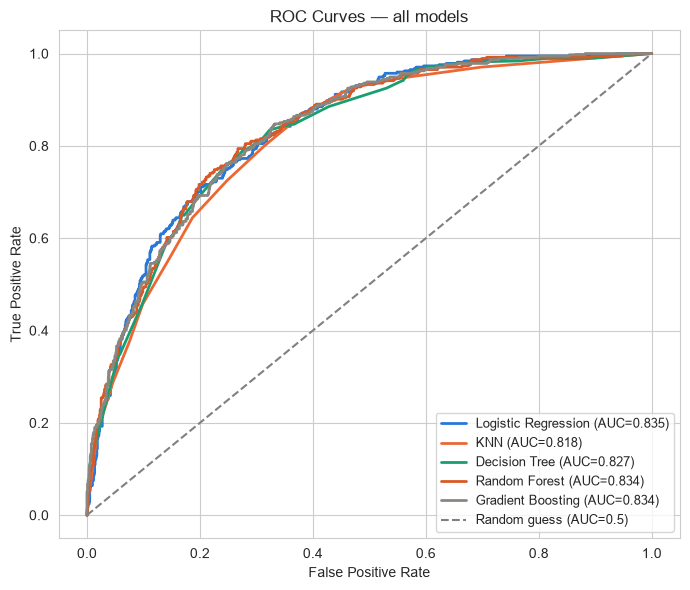

In [45]:
fig, ax = plt.subplots(figsize=(7,6))
colors = ['#2a78d6', '#eb6834', '#199e70', '#d95926', '#898781']

for (name, (fpr, tpr, _)), color in zip(roc_data.items(), colors):
    auc = results_df.loc[results_df.Model == name, 'ROC-AUC'].values[0]
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', color=color, linewidth=2)

ax.plot([0,1], [0,1], linestyle='--', color='gray', label='Random guess (AUC=0.5)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — all models')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

### 6.2 Confusion matrices

Raw counts of correct/incorrect predictions by class — useful to see *what kind* of mistakes each model makes, not just an aggregate score.

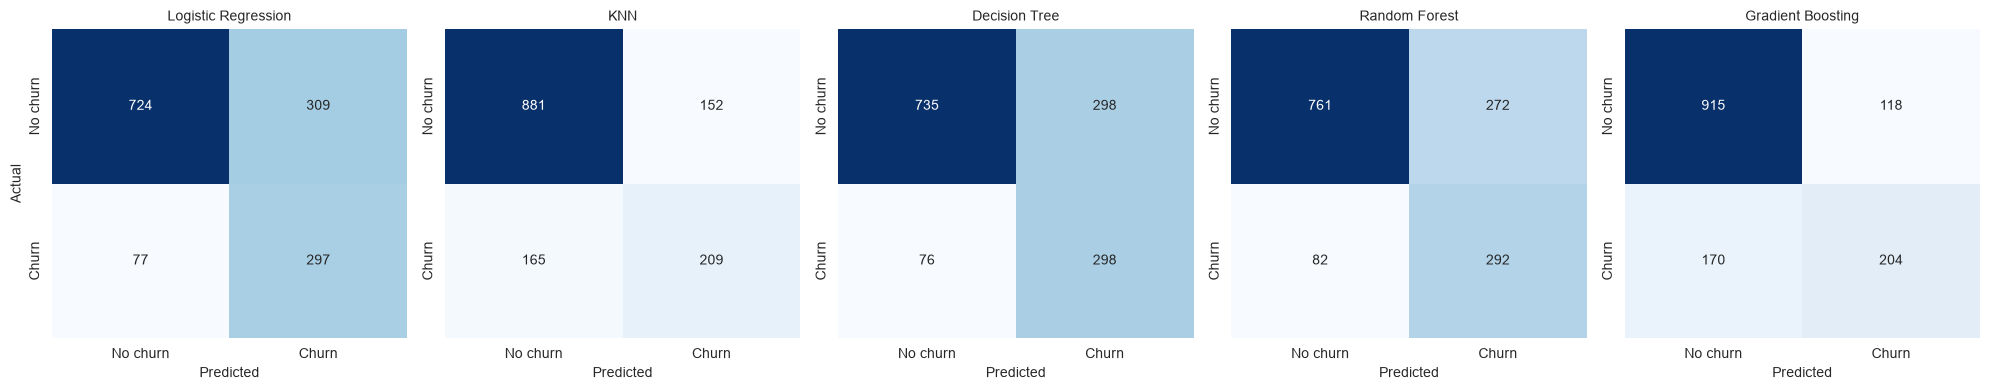

In [46]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for ax, (name, (model, needs_scaling)) in zip(axes, fitted_models.items()):
    X_eval = X_test_scaled if needs_scaling else X_test
    pred = model.predict(X_eval)
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
                xticklabels=['No churn', 'Churn'], yticklabels=['No churn', 'Churn'])
    ax.set_title(name, fontsize=10)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual' if name == list(fitted_models.keys())[0] else '')

plt.tight_layout()
plt.show()

### 6.3 Precision vs. recall trade-off — what it means for the business

Since ROC-AUC barely distinguishes the models, the real decision is which error type is more costly:

- **Random Forest** — best F1 (0.631), the best single balance of catching churners without too many false alarms. The safest default choice if you need one model.
- **Logistic Regression / Decision Tree** — highest recall (~0.79–0.80): catch the most actual churners, at the cost of more false positives. Best if retention outreach (a discount, a call) is cheap, so casting a wider net is fine even if some flagged customers wouldn't have churned anyway.
- **Gradient Boosting** — highest precision (0.633): when it flags someone as a churn risk, it's right more often, but it misses nearly half of actual churners (recall 0.559). Best if outreach is expensive or limited, and you want to spend it only on the highest-confidence cases.

There's no universally "best" model here — the right pick depends on the cost of a missed churner vs. the cost of a wasted retention offer, which is a business input, not a statistical one.

## Part 7: Feature Importance & Recommendations

Part 6 answered *how well* the models predict churn. This part answers *why* — which features actually drive those predictions — and translates that into recommendations someone outside this notebook can act on.

### 7.1 Feature importance (Random Forest)

Random Forest was the best-balanced model in Part 6 (highest F1), and tree-based importances are a natural fit for it — they measure how much each feature contributed to reducing impurity across all 300 trees.

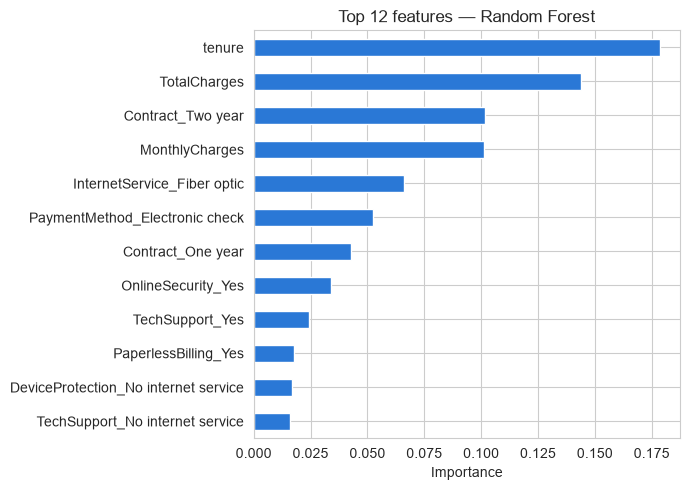

In [47]:
rf_model, _ = fitted_models['Random Forest']

importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)\
    .sort_values(ascending=False).head(12)

fig, ax = plt.subplots(figsize=(7,5))
importances.sort_values().plot(kind='barh', color='#2a78d6', ax=ax)
ax.set_xlabel('Importance')
ax.set_title('Top 12 features — Random Forest')
plt.tight_layout()
plt.show()

**`tenure` (0.182), `TotalCharges` (0.142), and `MonthlyCharges` (0.102) dominate** — together, over a third of total importance, confirming what Part 3's EDA already suggested visually. `Contract_Two year` (0.101) and `InternetService_Fiber optic` (0.066) are the next-strongest, followed by `PaymentMethod_Electronic check` (0.052). Everything after that (security/support add-ons, paperless billing) contributes real but smaller signal.

One caveat worth flagging: tree-based importance doesn't tell you the *direction* of the effect, only *how much* a feature mattered to the splits. For direction, we turn to Logistic Regression next.

### 7.2 Direction of effect (Logistic Regression odds ratios)

Logistic Regression coefficients, exponentiated into **odds ratios**, are directly interpretable: an odds ratio of 2.0 means that feature roughly *doubles* the odds of churn (holding other features fixed); 0.5 means it roughly *halves* it. This is a good complement to Random Forest's importance — one tells you magnitude, the other tells you direction.

In [48]:
lr_model, _ = fitted_models['Logistic Regression']

odds_ratios = pd.Series(np.exp(lr_model.coef_[0]), index=X_train_scaled.columns).sort_values(ascending=False)

print('Features that INCREASE churn odds most:')
print(odds_ratios.head(6).round(2))

print('\nFeatures that DECREASE churn odds most:')
print(odds_ratios.tail(6).round(2))

Features that INCREASE churn odds most:
InternetService_Fiber optic       3.11
TotalCharges                      1.83
PaymentMethod_Electronic check    1.51
StreamingTV_Yes                   1.47
StreamingMovies_Yes               1.45
MultipleLines_Yes                 1.40
dtype: float64

Features that DECREASE churn odds most:
OnlineSecurity_Yes    0.71
PhoneService_Yes      0.69
MonthlyCharges        0.62
Contract_One year     0.45
tenure                0.29
Contract_Two year     0.23
dtype: float64


**Increases risk:** `InternetService_Fiber optic` (odds x3.11), `TotalCharges` (x1.83), `PaymentMethod_Electronic check` (x1.51), streaming add-ons (x1.4-1.5).

**Decreases risk:** `Contract_Two year` (odds x0.23 — i.e. roughly a 77% *reduction* in churn odds vs. month-to-month), `tenure` (x0.29), `Contract_One year` (x0.45), `TechSupport_Yes` / `OnlineSecurity_Yes` (x0.71-0.74).

This lines up with the Random Forest importances and the raw EDA rates in Part 3 — contract length is the strongest lever in every view of the data we've taken.

### 7.3 Business recommendations

- **Push contract upgrades.** Month-to-month customers churn at roughly 15x the rate of two-year customers, and it's the top or near-top signal in every model. Even a modest incentive to move customers to a 1- or 2-year contract is likely the single highest-leverage retention action available.
- **Investigate the fiber optic experience.** Fiber customers pay more *and* churn more (odds x3.11 in the logistic model) — worth checking whether this reflects price sensitivity, service-quality complaints, or competitive pressure specific to fiber markets, rather than assuming price alone explains it.
- **Reduce friction on electronic check payments.** This payment method correlates with the highest churn of any payment type; nudging customers toward autopay (credit card or bank transfer) may help, since those methods show consistently lower churn.
- **Promote security/support add-ons.** `OnlineSecurity` and `TechSupport` both reduce churn odds by roughly 25-30%. This could be causal (fewer frustrations -> less churn) or could reflect that already-engaged customers buy more add-ons — worth testing with a targeted offer rather than assuming causation.
- **Prioritize the first 12 months.** Part 3 showed churn peaking at 47.7% in year one and dropping to 6.6% by year six. Early-tenure customers are the highest-risk group in absolute terms and the best target for proactive retention outreach, regardless of which other attributes they have.

### 7.4 Caveats & limitations

- **Correlation, not causation.** Every finding here — from the univariate EDA rates to the model-based importances and odds ratios — describes *association*, not proven cause and effect. A customer's contract, payment method, and add-ons are also correlated with each other and with unobserved factors (e.g. how price-sensitive or how tech-savvy they are), which no amount of feature importance can fully untangle.
- **No causal experiment was run.** Confirming that, say, incentivizing contract upgrades *causes* lower churn (rather than merely being associated with customers who were already going to stay) would need an A/B test — randomly offering the incentive to one group and comparing outcomes against a control group.
- **Model performance ceiling.** All five models converge around 0.82-0.85 ROC-AUC — additional feature engineering or more complex models are unlikely to move this much further without new data (e.g. customer service call logs, network quality metrics, competitor pricing in the customer's area).
- **Threshold not tuned.** All metrics in Part 6 used the default 0.5 probability cutoff. Since Gradient Boosting in particular under-predicts churners (recall 0.559), adjusting its decision threshold downward could trade some precision for meaningfully higher recall if that suits the business's cost trade-off better.

### 7.5 Suggested next steps

- Hyperparameter tuning (grid/random search) on Random Forest and Gradient Boosting, since neither has been tuned beyond the initial reasonable defaults used here.
- Threshold tuning on the chosen model's predicted probabilities, rather than defaulting to 0.5, guided by the actual cost of a false negative (missed churner) vs. false positive (wasted retention offer).
- A pilot A/B test on the top recommendation (contract-upgrade incentive) to move from correlational insight to a measured causal effect.
- If richer explanations per customer are needed (e.g. for a customer-success team to act on individually), SHAP values would give a per-customer breakdown of which features pushed their specific risk score up or down, rather than only the dataset-wide importances shown here.

## Conclusion

This notebook took the Telco Customer Churn dataset from raw CSV to a compared set of five churn-prediction models and a set of business-ready recommendations, following a standard data analysis workflow: **data understanding -> cleaning -> EDA -> feature engineering -> modeling -> evaluation -> interpretation.**

**Headline result:** contract length, tenure, and monthly/total charges are the dominant churn signals across every method used — univariate EDA, tree-based importance, and logistic regression coefficients all agree. Random Forest offers the best balanced predictive performance (F1 = 0.631), but the choice between it, Logistic Regression, and Gradient Boosting should ultimately be driven by the real-world cost of a missed churner vs. a wasted retention offer — a business input this notebook can inform but not decide on its own.